In [45]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [9]:
load_dotenv()

True

In [10]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=0.7
)

In [11]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="The sentiment of the review")

In [46]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    positive_sentiment: str
    negative_sentiment: str

In [48]:
def find_sentiment(state: ReviewState):
    prompt = f'For the given review, identify the sentiment: \n\n"{state.get("review", "")}"'
    structured_llm = llm.with_structured_output(SentimentSchema)
    response = structured_llm.invoke(prompt)
    return {'sentiment': response.sentiment}

In [49]:
def check_condition(state: ReviewState) -> Literal['positive_sentiment', 'negative_sentiment']:
    if state.get('sentiment') == 'positive':
        return 'positive_sentiment'
    else:
        return 'negative_sentiment'

In [50]:
def positive_sentiment(state: ReviewState):
    prompt = f"Given the following review, explain why the sentiment is positive:\n\n{state.get('review', '')}"
    response = llm.invoke(prompt)
    return {'positive_sentiment': response.content}

In [51]:
def negative_sentiment(state: ReviewState):
    prompt = f"Given the following review, explain why the sentiment is negative:\n\n{state.get('review', '')}"
    response = llm.invoke(prompt)
    return {'negative_sentiment': response.content}

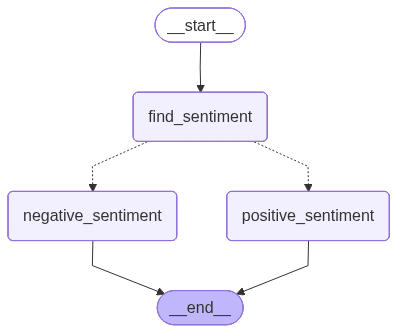

In [52]:
graph = StateGraph(ReviewState)
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_sentiment", positive_sentiment)
graph.add_node("negative_sentiment", negative_sentiment)
graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_condition)
graph.add_edge("positive_sentiment", END)
graph.add_edge("negative_sentiment", END)
workflow = graph.compile()
workflow

In [53]:
initial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}


final_output = workflow.invoke(initial_state)

In [57]:
print(final_output)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'sentiment': 'negative', 'negative_sentiment': 'The sentiment of this review is unequivocally negative due to several key factors:\n\n1.  **Inability to Access Basic Functionality:** The core issue is that the user cannot log in, which is the most fundamental step for using almost any app. The phrase "trying to log in for over an hour now" highlights a complete failure of the app\'s primary purpose.\n2.  **Persistent Technical Problem:** The app "keeps freezing on the authentication screen" indicates a recurring, unresolvable bug. This suggests instability and poor performance.\n3.  **User Effort Wasted:** The user attempted a common troubleshooting step ("I even tried reinstalling it") but it yielded "no luck." This adds to the frustration, as 